REBOUND Laplace resonance explorations

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import rebound

1.0000235297231757 0.4983224356417284 0.24732588361646157
6.283037469047238 12.608674339713888 25.404479366677126


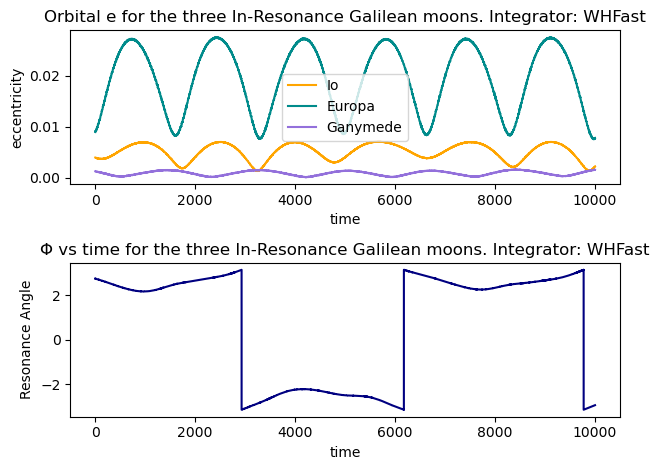

In [55]:
# set up a simulation of a central mass with 3 orbiting bodies in 4:2:1 resonance. 
# This 4:2:1 ratio is what defines a Laplace resonance. 
# While it is technically possible to pull real data, doing so makes the units unpleasant
Laplace_res_sim = rebound.Simulation()
Laplace_res_sim.add(m=1.0) #masses now measured in Jupiter masses

# Io mass (units of Jupiter masses)
m_Io = 4.706e-5

# Europa mass (units of Jupiter masses)
m_Europa = 2.529e-5

# Ganymede mass (units of Jupiter masses)
m_Ganymede = 7.808e-5

Laplace_res_sim.add(m=m_Io, a=1, e=0.004, f=np.random.rand()*2.0*np.pi) #1 distance unit is now ~2.819x10^(-3) AU. Also, starting the moons at some random points in their orbits.
Laplace_res_sim.add(m=m_Europa, a=1.5910, e=0.009, f=np.random.rand()*2.0*np.pi)
Laplace_res_sim.add(m=m_Ganymede, a=2.5381, e=0.0013, f=np.random.rand()*2.0*np.pi) #no inclinations currently included. Might change that later. 

Laplace_res_sim.move_to_com()

Orbits = Laplace_res_sim.orbits()
print(Orbits[0].n, Orbits[1].n, Orbits[2].n) #mean motions of Io, Europa, Ganymede
print(Orbits[0].P, Orbits[1].P, Orbits[2].P) #orbital periods of Io, Europa, Ganymede
#those are actually off by a little bit. it should be closer to 2pi, 4pi, 8pi.

# choose integrator and set timestep 
Laplace_res_sim.integrator = 'whfast'
Laplace_res_sim.dt = 0.3

times = np.linspace(0.0, 10000, 50000)
output_times = []
eccentricities = []
resonance_angles = []

for t in times:
    # do the sim
    Laplace_res_sim.integrate(t, exact_finish_time=0)

    # store times
    output_times.append(Laplace_res_sim.t)

    # assign orbits
    orbits = Laplace_res_sim.orbits()

    # store e's
    eccentricities.append((orbits[0].e, orbits[1].e, orbits[2].e))

    # get mean longitudes for resonance angle
    lambda_Io = orbits[0].l
    lambda_Europa = orbits[1].l
    lambda_Ganymede = orbits[2].l

    # calculate resonance angle φ; easy since the ratios are known
    phi = lambda_Io - 3*lambda_Europa + 2*lambda_Ganymede

    # wrap φ to -π to π for data visualization
    phi = np.arctan2(np.sin(phi), np.cos(phi))

    # store resonance angles φ
    resonance_angles.append(phi)


# clean up some data storage stuff
eccentricities = np.array(eccentricities)
resonance_angles = np.array(resonance_angles)
Io_eccentricities = eccentricities[:, 0]
Europa_eccentricities = eccentricities[:, 1]
Ganymede_eccentricities = eccentricities[:, 2]


# plots! 
# eccentricities vs time
plt.subplot(2, 1, 1)
plt.plot(output_times, Io_eccentricities, label='Io', color='orange')
plt.plot(output_times, Europa_eccentricities, label='Europa', color='darkcyan')
plt.plot(output_times, Ganymede_eccentricities, label='Ganymede', color='mediumpurple')
plt.title('Orbital e for the three In-Resonance Galilean moons. Integrator: WHFast')
plt.xlabel('time')
plt.ylabel('eccentricity')
plt.legend()

# resonance angle vs time
plt.subplot(2, 1, 2)
plt.plot(output_times, resonance_angles, color='navy')
plt.xlabel('time')
plt.ylabel('Resonance Angle')
plt.title('Φ vs time for the three In-Resonance Galilean moons. Integrator: WHFast')

plt.tight_layout()

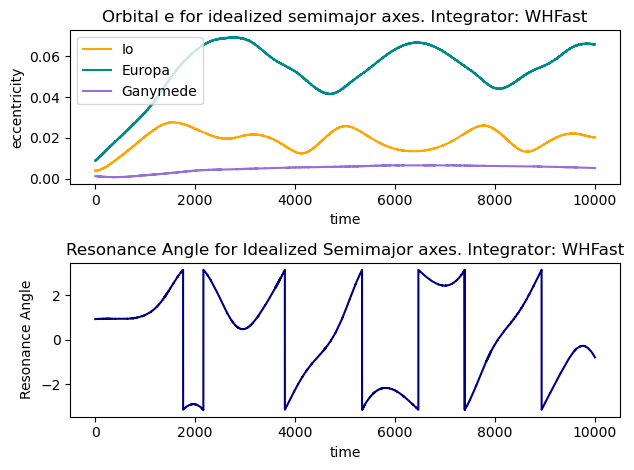

In [57]:
# the same simulation as above, but with the semimajor axes altered to START OUT closer to 
# the ideal values of 1:1.574:2.5198

# setup
Laplace_res_sim_idealizedsemimaj = rebound.Simulation()
Laplace_res_sim_idealizedsemimaj.add(m=1.0)
Laplace_res_sim_idealizedsemimaj.add(m=m_Io, a=1, e=0.004, f=np.random.rand()*2.0*np.pi)
Laplace_res_sim_idealizedsemimaj.add(m=m_Europa, a=1.5874, e=0.009, f=np.random.rand()*2.0*np.pi)
Laplace_res_sim_idealizedsemimaj.add(m=m_Ganymede, a=2.5198, e=0.0013, f=np.random.rand()*2.0*np.pi)

# bookkeeping
Laplace_res_sim_idealizedsemimaj.move_to_com()
Orbit_idealizedsemimaj = Laplace_res_sim_idealizedsemimaj.orbits()

# choose integrator and set timestep 
Laplace_res_sim_idealizedsemimaj.integrator = 'whfast'
Laplace_res_sim_idealizedsemimaj.dt = 0.3

# more bookkeeping
times_idealizedsemimaj = np.linspace(0.0, 10000, 50000)
output_times_idealizedsemimaj = []
eccentricities_idealizedsemimaj = []
resonance_angles_idealizedsemimaj = []

# do the simulations
for t in times:
    Laplace_res_sim_idealizedsemimaj.integrate(t, exact_finish_time=0) #Don't break the simplectic nature of the integrator by forcing it to go to my exact end times!
    output_times_idealizedsemimaj.append(Laplace_res_sim_idealizedsemimaj.t)
    orbits = Laplace_res_sim_idealizedsemimaj.orbits()
    eccentricities_idealizedsemimaj.append((orbits[0].e, orbits[1].e, orbits[2].e))
    lambda_Io = orbits[0].l
    lambda_Europa = orbits[1].l
    lambda_Ganymede = orbits[2].l
    phi = lambda_Io - 3*lambda_Europa + 2*lambda_Ganymede
    phi = np.arctan2(np.sin(phi), np.cos(phi))
    resonance_angles_idealizedsemimaj.append(phi)

# clean up some data storage stuff
eccentricities_idealizedsemimaj = np.array(eccentricities_idealizedsemimaj)
resonance_angles_idealizedsemimaj = np.array(resonance_angles_idealizedsemimaj)
Io_eccentricities_idealizedsemimaj = eccentricities_idealizedsemimaj[:, 0]
Europa_eccentricities_idealizedsemimaj = eccentricities_idealizedsemimaj[:, 1]
Ganymede_eccentricities_idealizedsemimaj = eccentricities_idealizedsemimaj[:, 2]

# plots; eccentricities vs time
plt.subplot(2, 1, 1)
plt.plot(output_times_idealizedsemimaj, Io_eccentricities_idealizedsemimaj, label='Io', color='orange')
plt.plot(output_times_idealizedsemimaj, Europa_eccentricities_idealizedsemimaj, label='Europa', color='darkcyan')
plt.plot(output_times_idealizedsemimaj, Ganymede_eccentricities_idealizedsemimaj, label='Ganymede', color='mediumpurple')
plt.title('Orbital e for idealized semimajor axes. Integrator: WHFast')
plt.xlabel('time')
plt.ylabel('eccentricity')
plt.legend()

# resonance angle vs time
plt.subplot(2, 1, 2)
plt.plot(output_times_idealizedsemimaj, resonance_angles_idealizedsemimaj, color='navy')
plt.xlabel('time')
plt.ylabel('Resonance Angle')
plt.title('Resonance Angle for Idealized Semimajor axes. Integrator: WHFast')

plt.tight_layout()

A fascinating effect has appeared here. Larger magnitude variations in the eccentricities can be clearly seen when the semimajor axes begin as idealized. In both cases, the locations of the moons within their orbits also affects the eccentricity